# Tutorial 1e: Design a Doublet, End to End

*Last verified against Optiland v0.6.1.*

Every other tutorial teaches one part of Optiland. This one carries a single
design all the way through, so you can see how the parts connect:

**requirements → first-order layout → a working design → analysis → optimization →
tolerancing → prescription**

The design is an achromatic doublet — the simplest lens worth designing properly. If you
have worked through
[Tutorial 1a](Tutorial_1a_Optiland_for_Beginners.ipynb) and
[Tutorial 1b](Tutorial_1b_Lens_Properties_and_Prescription.ipynb), you have everything
you need. If a convention here surprises you, the
[Conventions](../conventions.rst) page is the place to check.

## 1. Requirements

Every design starts as a specification. Ours:

| Requirement | Value |
|---|---|
| Effective focal length | 100 mm |
| Entrance pupil diameter | 20 mm (so f/5) |
| Half field of view | ±2° |
| Waveband | visible: F (0.4861 µm), d (0.5876 µm), C (0.6563 µm) |
| Goal | diffraction-limited-ish on axis, small chromatic blur across the band |

Two numbers matter before anything else: the **Airy radius** at f/5 in the visible is
about 1.22 λ·(f/#) ≈ 3.6 µm, and the **detector pixel** we are notionally aiming at is
around 5 µm. So an RMS spot radius in the single-digit microns is "good", and anything
tens of microns is not.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from optiland.analysis import RayFan, RmsSpotSizeVsField, SpotDiagram
from optiland.diagnostics import check_system
from optiland.optic import Optic

WAVELENGTHS = (0.4861, 0.5876, 0.6563)  # F, d, C
EPD = 20.0
HALF_FOV = 2.0


def apply_system_spec(lens: Optic) -> Optic:
    """Apply the aperture, fields and wavelengths from the requirements."""
    lens.set_aperture(aperture_type="EPD", value=EPD)
    lens.fields.set_type("angle")
    for y in (0.0, 0.7 * HALF_FOV, HALF_FOV):
        lens.fields.add(y=y)
    for value in WAVELENGTHS:
        lens.wavelengths.add(value=value, is_primary=(value == 0.5876))
    return lens


def rms_by_field(lens: Optic) -> list[float]:
    """Polychromatic RMS spot radius per field, in microns."""
    spot = SpotDiagram(lens)
    return [
        1000.0 * float(np.mean([float(w) for w in field]))
        for field in spot.rms_spot_radius()
    ]

## 2. First-order layout: a singlet

Before choosing glass or worrying about aberrations, get the *first-order* system right:
a single positive element with the required focal length and aperture. This is the
honest starting point — and it is also a useful baseline to measure against.

A plano-convex N-BK7 singlet with R₁ ≈ 51.7 mm gives roughly 100 mm of focal length.

In [2]:
singlet = Optic(name="f/5 Singlet (baseline)")
singlet.surfaces.add(index=0, thickness=np.inf)                                   # object
singlet.surfaces.add(index=1, radius=51.68, thickness=8.0,
                     material="N-BK7", is_stop=True)                              # front
singlet.surfaces.add(index=2, radius=np.inf, thickness=95.0)                      # back
singlet.surfaces.add(index=3)                                                     # image
apply_system_spec(singlet)

# Before tracing anything, check the system is fully specified.
check_system(singlet)

DiagnosticReport(errors=0, warnings=0)

`check_system` reports no errors, so the system is complete. Place the image plane at
the paraxial focus with `image_solve()`, then look at it.

EFL:  100.00 mm
f/#:  5.00


(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

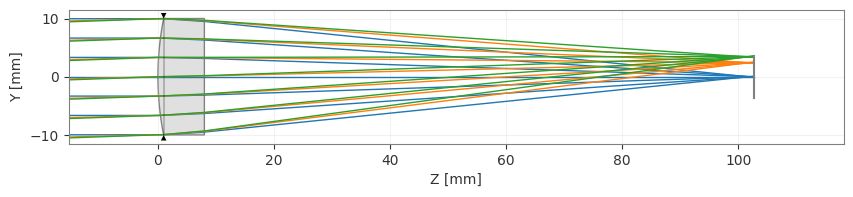

In [3]:
singlet.updater.image_solve()
print(f"EFL:  {float(singlet.paraxial.f2()):.2f} mm")
print(f"f/#:  {float(singlet.paraxial.FNO()):.2f}")
singlet.draw(num_rays=7)

In [4]:
print("Singlet RMS spot radius by field (um):")
for y, r in zip((0.0, 1.4, 2.0), rms_by_field(singlet)):
    print(f"  {y:4.1f} deg : {r:7.2f}")

Singlet RMS spot radius by field (um):
   0.0 deg :   84.36
   1.4 deg :   90.19
   2.0 deg :   96.38


Around **85 µm** on axis — more than twenty times the Airy radius. The layout meets the
first-order requirement and fails the image-quality requirement completely. Look at the
spot diagram to see *why*.

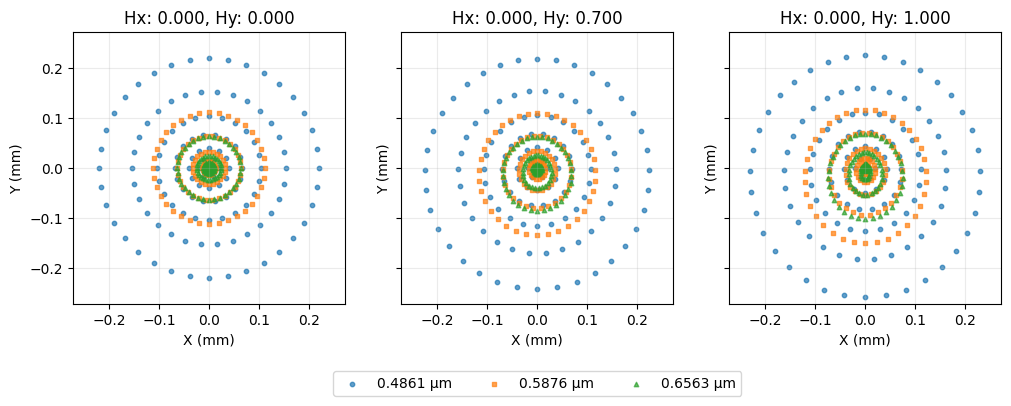

(<Figure size 1200x400 with 3 Axes>,
 [<Axes: title={'center': 'Hx: 0.000, Hy: 0.000'}, xlabel='X (mm)', ylabel='Y (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 0.700'}, xlabel='X (mm)', ylabel='Y (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 1.000'}, xlabel='X (mm)', ylabel='Y (mm)'>])

In [5]:
SpotDiagram(singlet).view()

The three wavelengths land on three different focal planes: this is **axial chromatic
aberration**, and no amount of bending a single element will remove it. That is the
problem an achromatic doublet exists to solve.

## 3. A real starting point: the cemented doublet

An achromat cements a positive crown element to a negative flint element. The two glasses
have different dispersions, so the combination can be made to focus F and C light at the
same place while keeping net positive power.

We use N-BK7 (crown) and N-SF5 (flint). Three radii define the shape: the front of the
crown, the cemented interface, and the back of the flint.

Note the "after" rule at work — surface 1 carries `material="N-BK7"` because the crown
glass lies *after* surface 1; surface 2 carries `material="N-SF5"` for the flint; and
surface 3 needs no material because air is the default.

EFL:  99.79 mm
f/#:  4.99


(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

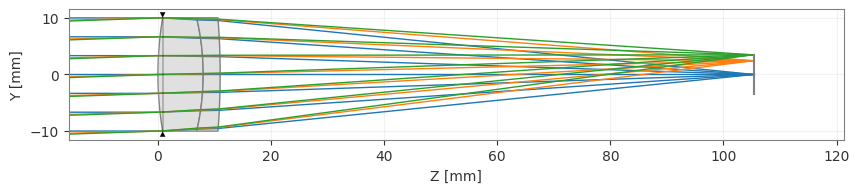

In [6]:
def build_doublet(r1=61.0, r2=-44.0, r3=-129.0, back=95.0) -> Optic:
    lens = Optic(name="Achromatic Doublet, f/5, EFL 100 mm")
    lens.surfaces.add(index=0, thickness=np.inf)                                  # object
    lens.surfaces.add(index=1, radius=r1, thickness=8.0,
                      material="N-BK7", is_stop=True)                             # crown
    lens.surfaces.add(index=2, radius=r2, thickness=3.0, material="N-SF5")        # cement
    lens.surfaces.add(index=3, radius=r3, thickness=back)                         # flint back
    lens.surfaces.add(index=4)                                                    # image
    return apply_system_spec(lens)


lens = build_doublet()
lens.updater.image_solve()
print(f"EFL:  {float(lens.paraxial.f2()):.2f} mm")
print(f"f/#:  {float(lens.paraxial.FNO()):.2f}")
lens.draw(num_rays=7)

In [7]:
print("Doublet RMS spot radius by field (um):")
for y, r in zip((0.0, 1.4, 2.0), rms_by_field(lens)):
    print(f"  {y:4.1f} deg : {r:7.2f}")

Doublet RMS spot radius by field (um):
   0.0 deg :    2.39
   1.4 deg :    8.10
   2.0 deg :   14.53


On axis the RMS spot radius drops from ~85 µm to a couple of microns — comparable to the
Airy radius. The full field is still worse, which is what the rest of the design work is
about.

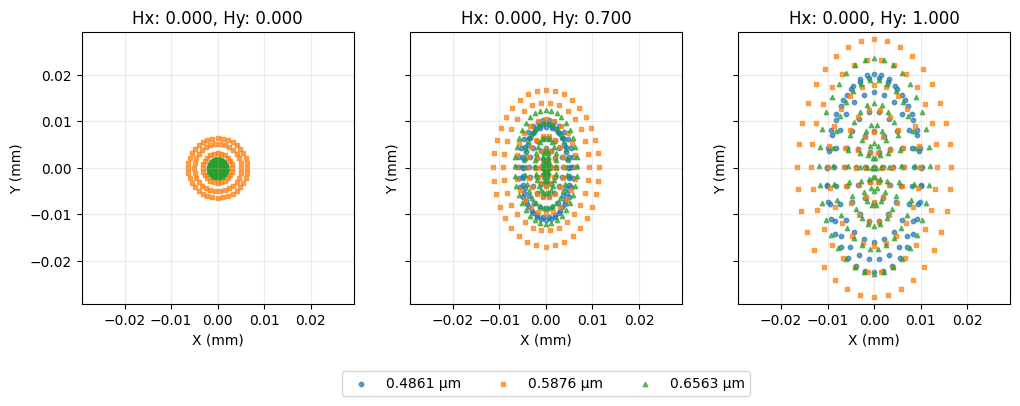

(<Figure size 1200x400 with 3 Axes>,
 [<Axes: title={'center': 'Hx: 0.000, Hy: 0.000'}, xlabel='X (mm)', ylabel='Y (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 0.700'}, xlabel='X (mm)', ylabel='Y (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 1.000'}, xlabel='X (mm)', ylabel='Y (mm)'>])

In [8]:
SpotDiagram(lens).view()

## 4. Analysis: where is the remaining error?

A spot diagram tells you *how big* the blur is. A ray fan tells you *what kind* of
aberration it is: the shape of the curve identifies the aberration, and its spread across
wavelengths identifies the chromatic content.

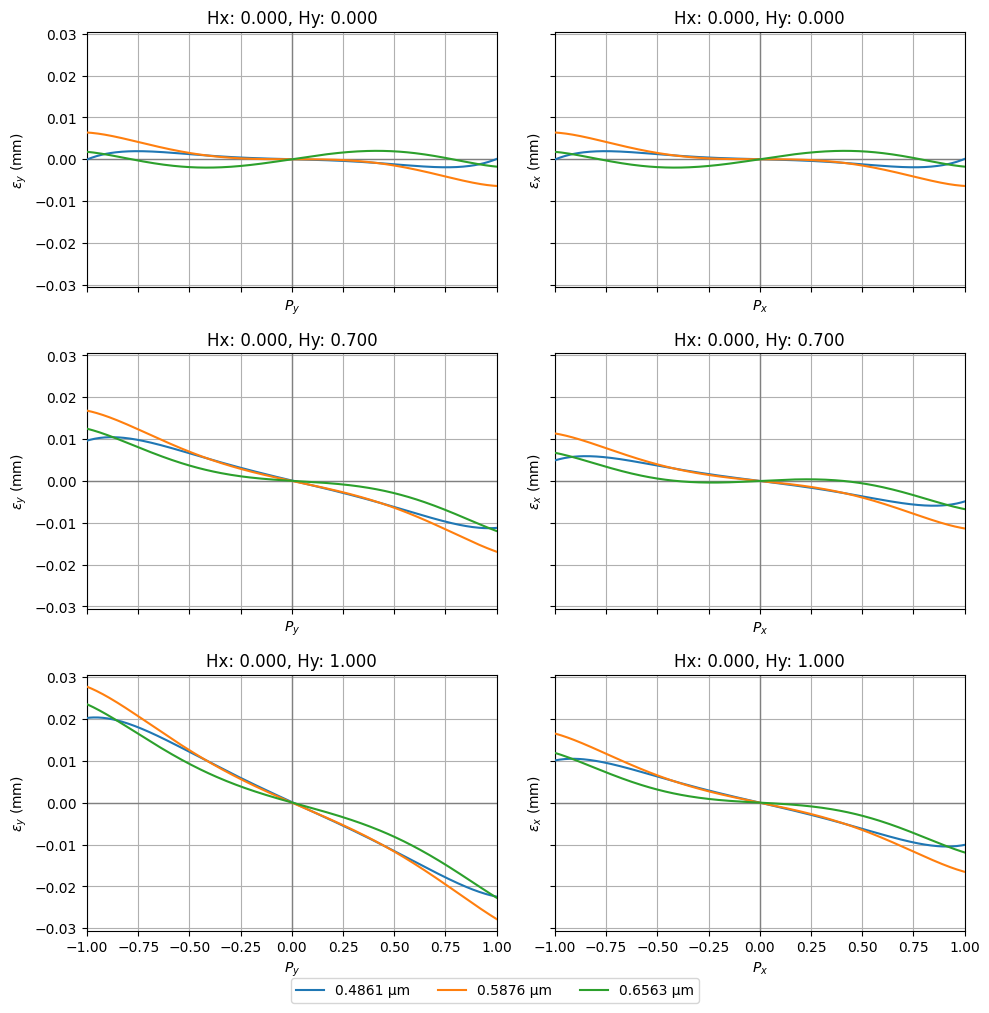

(<Figure size 1000x999 with 6 Axes>,
 [<Axes: title={'center': 'Hx: 0.000, Hy: 0.000'}, xlabel='$P_y$', ylabel='$\\epsilon_y$ (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 0.000'}, xlabel='$P_x$', ylabel='$\\epsilon_x$ (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 0.700'}, xlabel='$P_y$', ylabel='$\\epsilon_y$ (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 0.700'}, xlabel='$P_x$', ylabel='$\\epsilon_x$ (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 1.000'}, xlabel='$P_y$', ylabel='$\\epsilon_y$ (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 1.000'}, xlabel='$P_x$', ylabel='$\\epsilon_x$ (mm)'>])

In [9]:
RayFan(lens).view()

The on-axis curve is nearly flat with a slight S-shape — residual spherical aberration
and a small secondary spectrum. The off-axis curves tilt and separate: coma and field
curvature, both growing with field angle. That matches what the spot diagram showed.

`RmsSpotSizeVsField` makes the field dependence explicit:

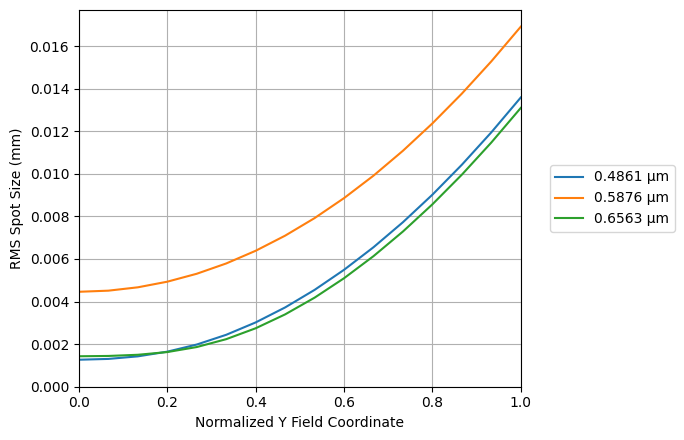

(<Figure size 700x450 with 1 Axes>,
 <Axes: xlabel='Normalized Y Field Coordinate', ylabel='RMS Spot Size (mm)'>)

In [10]:
RmsSpotSizeVsField(lens, num_fields=16).view()

## 5. Optimization

We have three free radii and one hard constraint (EFL = 100 mm). Optimization in Optiland
is always the same three steps:

1. declare **variables** — what may change,
2. declare **operands** — what "good" means, as targets,
3. hand the problem to an **optimizer**.

The EFL operand gets a heavy weight because it is a requirement, not a preference. The
spot-size operands are targeted at zero across three fields and three wavelengths.

In [11]:
from optiland.optimization import OptimizationProblem, OptimizerGeneric

problem = OptimizationProblem()

# 1. Variables: the three radii.
for surface_number in (1, 2, 3):
    problem.add_variable(lens, "radius", surface_number=surface_number)

# 2. Operands: hold the focal length, minimize the polychromatic spot.
problem.add_operand("f2", target=100.0, weight=10.0, input_data={"optic": lens})
for Hy in (0.0, 0.7, 1.0):
    for wavelength in WAVELENGTHS:
        problem.add_operand(
            "rms_spot_size",
            target=0.0,
            weight=1.0,
            input_data={
                "optic": lens,
                "Hx": 0.0,
                "Hy": Hy,
                "num_rings": 6,
                "wavelength": wavelength,
                "surface_number": -1,  # the image surface
            },
        )

print(f"Merit function before: {float(problem.sum_squared()):.6f}")

Merit function before: 4.520587


In [12]:
OptimizerGeneric(problem).optimize(maxiter=200)
lens.updater.image_solve()  # optimization moved the focus; refocus the image plane

print(f"Merit function after:  {float(problem.sum_squared()):.6f}")
print(f"EFL: {float(lens.paraxial.f2()):.3f} mm")
print("Radii:", [round(float(lens.surfaces.radii[i]), 3) for i in (1, 2, 3)])

Merit function after:  0.000679
EFL: 100.000 mm
Radii: [61.112, -43.937, -129.032]


In [13]:
print("Optimized RMS spot radius by field (um):")
for y, r in zip((0.0, 1.4, 2.0), rms_by_field(lens)):
    print(f"  {y:4.1f} deg : {r:7.2f}")

Optimized RMS spot radius by field (um):
   0.0 deg :    2.04
   1.4 deg :    7.40
   2.0 deg :   13.84


The EFL is now exactly on target and the spot is smaller at every field. The gain is
modest — a cemented doublet with a fixed glass pair has very few degrees of freedom, and
the starting point was already close. That is a real result, not a failure of the
optimizer: **knowing when a form is exhausted is part of design.** To do better you would
change the form — split the element, add an air space, or change the glass pair (see
[Tutorial 3e](Tutorial_3e_Glass_Expert_Categorical_Optimization.ipynb)).

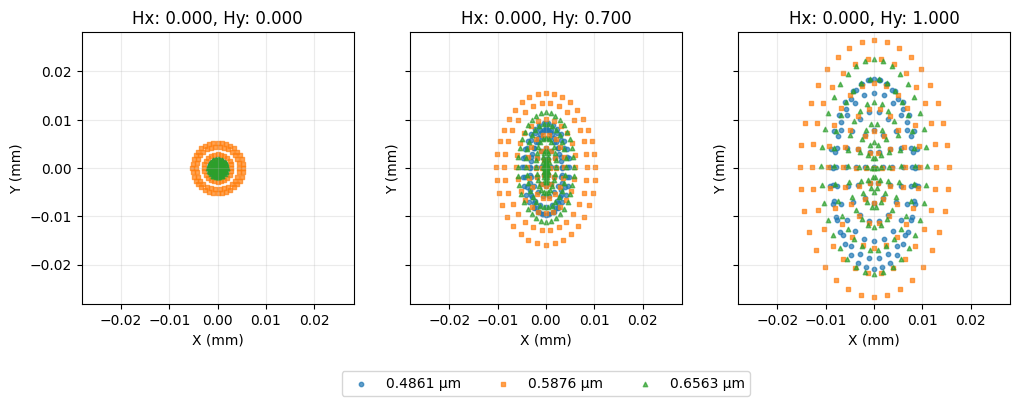

(<Figure size 1200x400 with 3 Axes>,
 [<Axes: title={'center': 'Hx: 0.000, Hy: 0.000'}, xlabel='X (mm)', ylabel='Y (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 0.700'}, xlabel='X (mm)', ylabel='Y (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 1.000'}, xlabel='X (mm)', ylabel='Y (mm)'>])

In [14]:
SpotDiagram(lens).view()

## 6. Tolerancing: will it survive manufacturing?

A design that only works at its nominal prescription is not a design. Tolerancing asks:
how much does performance degrade when the radii, thicknesses and alignments land within
realistic manufacturing bands?

Start with **sensitivity** — vary one parameter at a time and watch a performance metric.
This tells you which parameters need tight tolerances and which do not.

(<Figure size 990x500 with 6 Axes>,
 [<Axes: ylabel='0: f2'>,
  <Axes: >,
  <Axes: >,
  <Axes: xlabel='Radius of Curvature, Surface 1', ylabel='1: rms spot size'>,
  <Axes: xlabel='Thickness, Surface 1'>,
  <Axes: xlabel='Tilt X, Surface 1'>])

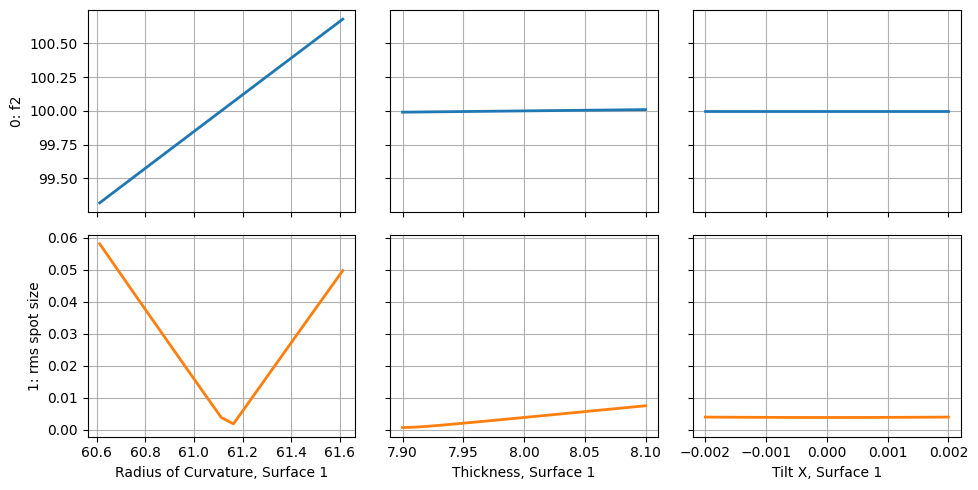

In [15]:
from optiland.tolerancing import RangeSampler, SensitivityAnalysis, Tolerancing

tolerancing = Tolerancing(lens)

r1 = float(lens.surfaces.radii[1])
tolerancing.add_perturbation(
    "radius", RangeSampler(start=r1 - 0.5, end=r1 + 0.5, steps=21), surface_number=1
)
tolerancing.add_perturbation(
    "thickness", RangeSampler(start=7.9, end=8.1, steps=21), surface_number=1
)
tolerancing.add_perturbation(
    "tilt", RangeSampler(start=-0.002, end=0.002, steps=21), surface_number=1, axis="x"
)

tolerancing.add_operand("f2", {"optic": lens})
tolerancing.add_operand(
    "rms_spot_size",
    {
        "optic": lens,
        "surface_number": -1,
        "Hx": 0.0,
        "Hy": 0.0,
        "wavelength": 0.5876,
        "num_rays": 6,
    },
    target=0.0,
)

sensitivity = SensitivityAnalysis(tolerancing)
sensitivity.run()
sensitivity.view()

Now a **Monte Carlo** run: perturb everything simultaneously from realistic
distributions and look at the resulting spread. This is the number you quote to a
manufacturer.

(<Figure size 1200x400 with 1 Axes>,
 array([<Axes: xlabel='0: rms spot size', ylabel='Density'>, <Axes: >,
        <Axes: >], dtype=object))

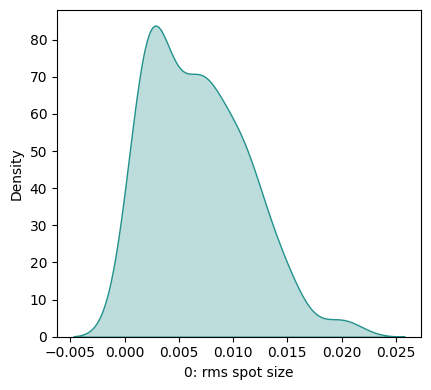

In [16]:
from optiland.tolerancing.monte_carlo import MonteCarlo
from optiland.tolerancing.perturbation import DistributionSampler

mc_tolerancing = Tolerancing(lens)

for surface_number in (1, 2, 3):
    # Radius: 0.1% of nominal, 1-sigma
    nominal = float(lens.surfaces.radii[surface_number])
    mc_tolerancing.add_perturbation(
        "radius",
        DistributionSampler("normal", loc=nominal, scale=abs(nominal) * 0.001),
        surface_number=surface_number,
    )
    # Element tilt: 1 arcmin, 1-sigma (radians)
    for axis in ("x", "y"):
        mc_tolerancing.add_perturbation(
            "tilt",
            DistributionSampler("normal", loc=0.0, scale=0.0003),
            surface_number=surface_number,
            axis=axis,
        )

mc_tolerancing.add_operand(
    "rms_spot_size",
    {
        "optic": lens,
        "surface_number": -1,
        "Hx": 0.0,
        "Hy": 0.0,
        "wavelength": 0.5876,
        "num_rays": 6,
    },
    target=0.0,
)

mc = MonteCarlo(mc_tolerancing)
mc.run(num_iterations=100)
mc.view_histogram()

In [17]:
results = mc.get_results()
results.describe()

,"Radius of Curvature, Surface 1","Tilt X, Surface 1","Tilt Y, Surface 1","Radius of Curvature, Surface 2","Tilt X, Surface 2","Tilt Y, Surface 2","Radius of Curvature, Surface 3","Tilt X, Surface 3","Tilt Y, Surface 3",0: rms spot size
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,61.119423,0.000050,0.000030,-43.935201,0.000061,-0.000022,-129.031451,-0.000035,0.000005,0.006800
std,0.047746,0.000293,0.000276,0.047804,0.000278,0.000294,0.125461,0.000305,0.000318,0.004475
min,61.015920,-0.000759,-0.000729,-44.035582,-0.000612,-0.001040,-129.372587,-0.000714,-0.000749,0.000640
25%,61.088062,-0.000137,-0.000154,-43.969531,-0.000102,-0.000187,-129.110373,-0.000241,-0.000198,0.002742
50%,61.117092,0.000051,0.000020,-43.936814,0.000074,-0.000039,-129.032931,-0.000028,0.000010,0.006527
75%,61.156181,0.000272,0.000240,-43.904015,0.000236,0.000161,-128.946334,0.000194,0.000212,0.009839
max,61.226683,0.000666,0.000741,-43.799970,0.000862,0.000729,-128.716980,0.000831,0.000781,0.020465


The distribution — not its mean — is the deliverable. If the 90th percentile of RMS spot
radius is still inside your budget, the design is manufacturable at these tolerances. If
not, tighten the parameter the sensitivity analysis flagged as worst, and rerun.

## 7. The prescription

Finally, produce the document you would hand to a colleague or a vendor: every surface,
every material, the first-order properties, and the residual aberrations.

In [18]:
from optiland.prescription import Prescription

Prescription(lens).view()

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Optical Prescription — Achromatic Doublet, f/5, EFL 100 mm                                                      │
╰──────────────────────────────────────── Generated: 2026-08-02 10:34 UTC ────────────────────────────────────────╯

───────────────────────────────────────────────── System Overview ─────────────────────────────────────────────────

 Name              Achromatic Doublet, f/5, EFL 100 mm  
  Surfaces          3                                    
  Stop Surface      1.0000                               
  Aperture Type     EPDAperture                          
  Aperture Value    20.0000                              
  Object Distance   ∞                                    
  Image Distance    94.6311                             

 Wavelengths

 #   Wavelength (µm)   Primary  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  1   0.4861                     
  2   0.5876            ✓        
  3   0.6563

...

 S#   Type       Radius (mm)   Thickness (mm)   Conic    Stop   Comment  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  0    Plane      ∞             ∞                —                        
  1    standard   61.1165       8.0000           0.0000   ✓               
  2    standard   -43.9737      3.0000           0.0000                   
  3    standard   -128.9639     94.6311          0.0000                   
  4    standard   ∞             0.0000           —

──────────────────────────────────────────── Surface Data — Materials ─────────────────────────────────────────────

 S#   Material   nd       Vd        Semi-Diameter (mm)   Coating  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  0    Air        1.0000   —         —                    —        
  1    N-BK7      1.5168   64.1673   —                    —        
  2    N-SF5      1.6727   32.2512   —                    —        
  3    Air        1.0000   —         —                    —        
  4    Air        1.0000   —         —                    —

───────────────────────────────────────── Seidel Aberration Coefficients ──────────────────────────────────────────

 S#      SI (Sph)    SII (Coma)   SIII (Astig)   SIV (Petz)   SV (Dist)   CL (LCA)    CT (TCA)   
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  1       -0.009840   -0.002100    -0.000448      -0.000680    -0.000241   -0.017383   -0.003710  
  2       0.030537    -0.002107    0.000145       0.000170     -0.000022   0.059326    -0.004093  
  3       -0.023319   0.004351     -0.000812      -0.000380    0.000222    -0.041340   0.007713   
  Total   -0.002623   0.000144     -0.001115      -0.000890    -0.000040   0.000603    -0.000089 

## What you just did

You took a written requirement, laid it out to first order, discovered the first-order
solution was not good enough, changed the *form* to fix the dominant aberration, measured
what was left, optimized within that form, established what tolerances the design can
survive, and produced a prescription. That loop is the whole job; every other tutorial in
this documentation deepens one step of it.

## Where to go next

- **[Tutorial 2c — Aberration Analyses](Tutorial_2c_Aberration_Analyses.ipynb)** — Seidel
  coefficients, wavefront error, and how to read them.
- **[Tutorial 2d — OPD, PSF and MTF](Tutorial_2d_OPD_PSF_and_MTF_Calculations.ipynb)** —
  diffraction-based image quality, the metric most specifications actually use.
- **[Tutorial 3d — Optimization Case Study](Tutorial_3d_Optimization_Case_Study_Cooke_Triplet.ipynb)**
  — the same loop on a form with real degrees of freedom.
- **[Tutorial 6a — Tolerancing Sensitivity](Tutorial_6a_Tolerancing_Sensitivity_Analysis.ipynb)**
  — tolerancing in depth, including compensators.
- **[How do I ...?](../how_do_i.rst)** — a task-shaped index over every notebook here.